In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from datetime import timedelta
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)


### **1. Tải và làm sạch dữ liệu**

In [2]:
df = pd.read_excel("Online_Retail.xlsx")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("Shape:", df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [ ]:
# Thay đổi thứ tự hiển thị các cột trong bảng dữ liệu (Customer ID và InvoiceDate)
# Lấy danh sách các cột hiện có
current_columns = df.columns.tolist()
print(f"Các cột hiện tại: {current_columns}")
new_column_order = ['CustomerID', 'InvoiceDate', 'InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'Country']
# Áp dụng thứ tự cột mới cho DataFrame
df = df[new_column_order]
print("\nDataFrame sau khi sắp xếp lại cột:")
display(df.head())

Các cột hiện tại: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

DataFrame sau khi sắp xếp lại cột:


,CustomerID,InvoiceDate,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
0,17850.0,2010-12-01 08:26:00,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,United Kingdom
1,17850.0,2010-12-01 08:26:00,536365,71053,WHITE METAL LANTERN,6,3.39,United Kingdom
2,17850.0,2010-12-01 08:26:00,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,United Kingdom
3,17850.0,2010-12-01 08:26:00,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,United Kingdom
4,17850.0,2010-12-01 08:26:00,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,United Kingdom


In [6]:
# Đếm số mặt hàng khác nhau trong tập dữ liệu
df['StockCode'].nunique()

4070

In [7]:
df[df['StockCode'].str.contains('B', na=False)]

,CustomerID,InvoiceDate,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
2,17850.0,2010-12-01 08:26:00,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,United Kingdom
51,17850.0,2010-12-01 09:02:00,536373,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,United Kingdom
68,17850.0,2010-12-01 09:32:00,536375,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,United Kingdom
90,14688.0,2010-12-01 09:37:00,536378,84997B,RED 3 PIECE RETROSPOT CUTLERY SET,12,3.75,United Kingdom
101,14688.0,2010-12-01 09:37:00,536378,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,48,1.25,United Kingdom
...,...,...,...,...,...,...,...,...
541673,14446.0,2011-12-09 11:34:00,581538,84519B,CARROT CHARLIE+LOLA COASTER SET,1,1.25,United Kingdom
541674,14446.0,2011-12-09 11:34:00,581538,35004B,SET OF 3 BLACK FLYING DUCKS,2,5.45,United Kingdom
541687,14446.0,2011-12-09 11:34:00,581538,79191B,RETRO PLASTIC POLKA TRAY,1,0.85,United Kingdom
541698,14446.0,2011-12-09 11:34:00,581538,35004B,SET OF 3 BLACK FLYING DUCKS,1,5.45,United Kingdom


In [8]:
df.describe()
## Dùng để xác định các thao tác làm sạch dữ liệu tiếp theo
# Cột InvoiceDate, Quantity và UnitPrice đều có 541,909 dòng. Nhưng cột CustomerID chỉ có 406,829 dòng nên phải xóa những dòng bị thiếu Customer ID
# Min (Giá trị nhỏ nhất) của cột Quantity bị âm (tức là hàng bị trả lại) thì tí nữa chúng tôi lọc những đơn hàng có quantity âm
# Min của cột UnitPrice bị âm nên cũng phải lọc UnitPrice < = 0


,CustomerID,InvoiceDate,Quantity,UnitPrice
count,406829.000000,541909,541909.000000,541909.000000
mean,15287.690570,2011-07-04 13:34:57.156386,9.552250,4.611114
min,12346.000000,2010-12-01 08:26:00,-80995.000000,-11062.060000
25%,13953.000000,2011-03-28 11:34:00,1.000000,1.250000
50%,15152.000000,2011-07-19 17:17:00,3.000000,2.080000
75%,16791.000000,2011-10-19 11:27:00,10.000000,4.130000
max,18287.000000,2011-12-09 12:50:00,80995.000000,38970.000000
std,1713.600303,NaN,218.081158,96.759853


In [9]:
# Loại bỏ trùng lặp
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

5268
0


In [10]:
# Xóa bỏ các dòng dữ liệu missing của Customer ID
df.dropna(subset = ['CustomerID'],  inplace=True)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [11]:
# Biến dữ liệu CustomerID thành số nguyên để loại bỏ số sau dấu phẩy rồi chuyển sang dạng văn bản
df['CustomerID'] = df['CustomerID'].astype(int)

In [12]:
df_full = df.copy()
df_full['TotalAmount'] = df_full['Quantity'] * df_full['UnitPrice']
df_full['is_cancel'] = df_full['InvoiceNo'].astype(str).str.startswith('C')
df_full['is_return'] = df_full['Quantity'] < 0

In [13]:
# df1 là data đã loại bỏ những giao dịch không hợp lệ
df1 = df_full[
    (df_full['Quantity'] > 0) &
    (df_full['UnitPrice'] > 0) &
    (~df_full['is_cancel'])
].copy()

# Kiểm tra lại số lượng
print(f"Số dòng đầy đủ (df_full): {len(df_full)}")
print(f"Số dòng hợp lệ (df1): {len(df1)}")
print("Số lượng giá trị trống trong df_full:")
print(df_full.isnull().sum())


Số dòng đầy đủ (df_full): 401604
Số dòng hợp lệ (df1): 392692
Số lượng giá trị trống trong df_full:
CustomerID     0
InvoiceDate    0
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
UnitPrice      0
Country        0
TotalAmount    0
is_cancel      0
is_return      0
dtype: int64


In [15]:
# Kiểm tra dữ liệu sau khi được làm sạch
df1.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   CustomerID   392692 non-null  int64         
 1   InvoiceDate  392692 non-null  datetime64[us]
 2   InvoiceNo    392692 non-null  object        
 3   StockCode    392692 non-null  object        
 4   Description  392692 non-null  object        
 5   Quantity     392692 non-null  int64         
 6   UnitPrice    392692 non-null  float64       
 7   Country      392692 non-null  str           
 8   TotalAmount  392692 non-null  float64       
 9   is_cancel    392692 non-null  bool          
 10  is_return    392692 non-null  bool          
dtypes: bool(2), datetime64[us](1), float64(2), int64(2), object(3), str(1)
memory usage: 30.7+ MB


In [16]:
# Kiểm tra lại xem còn dữ liệu UnitPrice < 0
df1[df1['UnitPrice'] <=0].head()

,CustomerID,InvoiceDate,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,TotalAmount,is_cancel,is_return


In [17]:
# Kiểm tra dữ liệu lạ
df1['Country'].unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Finland',
              'Austria',               'Greece',            'Singapore',
              'Lebanon', 'United Arab Emirates',               'Israel',
         'Saudi Arabia',       'Czech Republic',               'Canada',
          'Unspecified',               'Brazil',                  'USA',
   'European Community',              'Bahrain',                'Malta',
                  'RSA']
Length: 37, dtype: str

In [18]:
# Tạo biến mới Total Price
df1['Total_price'] = df1['Quantity'] * df1['UnitPrice']

In [19]:
# Khảo sát độ dài dữ liệu
print(df1['InvoiceDate'].min())
print(df1['InvoiceDate'].max())

# Giữ nguyên df1 full-range để phục vụ bài toán churn 90 ngày
# Tạo riêng một bản cắt thời gian cho phần RFM minh hoạ
df_rfm = df1[df1['InvoiceDate'] < '2011-11-30'].copy()

now = df_rfm['InvoiceDate'].max() + pd.DateOffset(days=1)  # cộng thêm một ngày cho dễ tính recency (tránh để recency = 0)
now

2010-12-01 08:26:00
2011-12-09 12:50:00


Timestamp('2011-11-30 18:14:00')

In [20]:
# Lập hàm tính Recency
lambda x: (now - x.max()).days

<function __main__.<lambda>(x)>

In [21]:
# Tạo R,F,M
rfm = df_rfm.groupby('CustomerID').agg(
        Recency = ('InvoiceDate', lambda x: (now - x.max()).days),
        Frequency = ('InvoiceNo' , 'nunique'),
        Monetary = ('Total_price', 'sum')
          )


In [22]:
#
rfm['r_score'] = pd.qcut(x = rfm['Recency'] , q = 5, labels = [5,4,3,2,1])
rfm['m_score'] = pd.qcut(x = rfm['Monetary'], q = 5 , labels = [1,2,3,4,5])
rfm.head()

,Recency,Frequency,Monetary,r_score,m_score
CustomerID,,,,,
12346,316,1,77183.60,1,5
12347,30,6,4085.18,4,5
12348,66,4,1797.24,3,4
12349,9,1,1757.55,5,4
12350,301,1,334.40,1,2


Frequency
1     1545
2      807
3      514
4      379
5      225
6      169
7      134
8       95
9       57
11      51
Name: count, dtype: int64

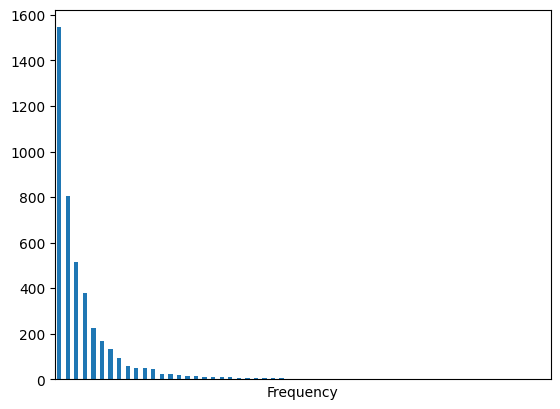

In [50]:
# Kiểm tra Frequency của data thấy được Frequency = 1 là cao nhất sau đó = 2 tức là có rất nhiều khách vãng lai
display(rfm['Frequency'].value_counts().head(10))
rfm['Frequency'].value_counts().plot(kind = 'bar')
plt.xticks([])
plt.show()


In [24]:
# Phân loại khách hàng theo R,F,M score
rfm['f_score'] = pd.qcut(x=rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm.head()

,Recency,Frequency,Monetary,r_score,m_score,f_score
CustomerID,,,,,,
12346,316,1,77183.60,1,5,1
12347,30,6,4085.18,4,5,5
12348,66,4,1797.24,3,4,4
12349,9,1,1757.55,5,4,1
12350,301,1,334.40,1,2,1


In [25]:
# Phân nhóm các khách hàng có cùng Frequency = 1 bằng F score
rfm[rfm["Frequency"]==1]['f_score'].value_counts()

f_score
1    859
2    686
3      0
4      0
5      0
Name: count, dtype: int64

In [26]:
# Chuyển R và F score thành string để kết hợp tạo thành RF score
rfm['rf_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str)
rfm.head()

,Recency,Frequency,Monetary,r_score,m_score,f_score,rf_score
CustomerID,,,,,,,
12346,316,1,77183.60,1,5,1,11
12347,30,6,4085.18,4,5,5,45
12348,66,4,1797.24,3,4,4,34
12349,9,1,1757.55,5,4,1,51
12350,301,1,334.40,1,2,1,11


In [27]:
# Phân nhóm từng loại khách hàng
segment_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At-Risk',
    r'[1-2]5': 'Cannot Lose Them',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}
segment_map

{'[1-2][1-2]': 'Hibernating',
 '[1-2][3-4]': 'At-Risk',
 '[1-2]5': 'Cannot Lose Them',
 '3[1-2]': 'About to Sleep',
 '33': 'Need Attention',
 '[3-4][4-5]': 'Loyal Customers',
 '41': 'Promising',
 '51': 'New Customers',
 '[4-5][2-3]': 'Potential Loyalists',
 '5[4-5]': 'Champions'}

In [28]:
# Tạo cột segment cho khách hàng dựa trên RF score
rfm['segment'] = rfm['rf_score'].replace(segment_map, regex=True)
rfm.head()

,Recency,Frequency,Monetary,r_score,m_score,f_score,rf_score,segment
CustomerID,,,,,,,,
12346,316,1,77183.60,1,5,1,11,Hibernating
12347,30,6,4085.18,4,5,5,45,Loyal Customers
12348,66,4,1797.24,3,4,4,34,Loyal Customers
12349,9,1,1757.55,5,4,1,51,New Customers
12350,301,1,334.40,1,2,1,11,Hibernating


In [29]:
# Đánh giá định lượng các phân khúc khách hàng
rfm.groupby('segment').agg({"Recency":'mean',
                            'Frequency':'mean',
                            "Monetary":['mean','count']})

Recency  Frequency     Monetary      
                           mean       mean         mean count
segment                                                      
About to Sleep        51.239884   1.118497   455.650408   346
At-Risk              153.570000   2.780000  1033.393002   600
Cannot Lose Them     129.383562   7.890411  2793.039589    73
Champions              6.661290  11.327419  6052.492726   620
Hibernating          217.174464   1.075049   475.260361  1026
Loyal Customers       32.867500   6.745000  3193.312364   800
Need Attention        50.413613   2.319372   983.306131   191
New Customers          7.126984   1.000000   311.092063    63
Potential Loyalists   15.638075   1.884937   646.003556   478
Promising             22.568421   1.000000   379.225789    95

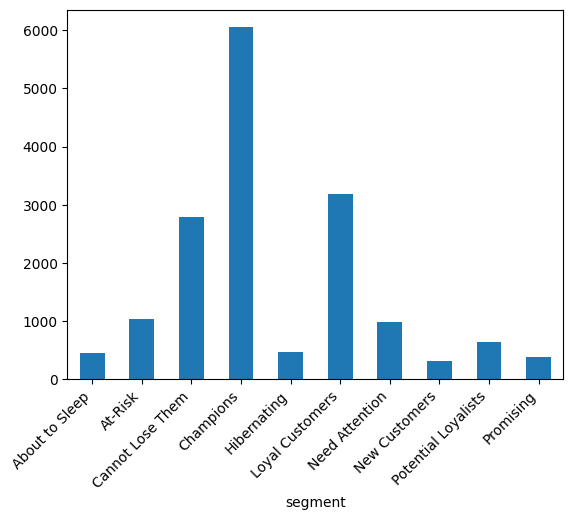

In [51]:
# Đánh giá giá trị kinh tế của các phân khúc khách hàng để xác định được nhóm Champions và Loyal Customers làm nhóm khách hàng chủ chốt
rfm.groupby('segment')['Monetary'].mean().plot(kind='bar')
plt.xticks(rotation=45, ha='right')
plt.show()

In [31]:
# Phân tích sức nặng doanh thu của phân khúc Champions (=45%)
rfm[rfm['segment'] =='Champions']['Monetary'].sum()/rfm['Monetary'].sum()

np.float64(0.4505602056844732)

In [32]:
# Định danh hành vi khách hàng qua chỉ số RFM_Score tổng hợp
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)
rfm.head()

,Recency,Frequency,Monetary,r_score,m_score,f_score,rf_score,segment,rfm_score
CustomerID,,,,,,,,,
12346,316,1,77183.60,1,5,1,11,Hibernating,115
12347,30,6,4085.18,4,5,5,45,Loyal Customers,455
12348,66,4,1797.24,3,4,4,34,Loyal Customers,344
12349,9,1,1757.55,5,4,1,51,New Customers,514
12350,301,1,334.40,1,2,1,11,Hibernating,112


In [33]:
# Đặc điểm phân khúc Champions
champions = rfm[rfm['segment']=='Champions']
champions.head()

,Recency,Frequency,Monetary,r_score,m_score,f_score,rf_score,segment,rfm_score
CustomerID,,,,,,,,,
12380,12,4,2724.81,5,5,4,54,Champions,545
12388,6,6,2780.66,5,5,5,55,Champions,555
12395,10,12,3018.63,5,5,5,55,Champions,555
12421,6,4,807.04,5,3,4,54,Champions,543
12437,12,16,4493.10,5,5,5,55,Champions,555


In [34]:
# Phân tích cấu trúc nội bộ phân khúc Champions
champions['rfm_score'].value_counts()

rfm_score
555    308
544    104
554     84
543     64
545     38
542     12
553      7
541      1
552      1
551      1
Name: count, dtype: int64

In [35]:
# Chuẩn hóa dữ liệu đầu vào cho mô hình dự báo
df = df1.copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)

if 'Total_price' not in df.columns:
    df['Total_price'] = df['Quantity'] * df['UnitPrice']

df = df.sort_values(['CustomerID', 'InvoiceDate']).copy()

print("Min date:", df['InvoiceDate'].min())
print("Max date:", df['InvoiceDate'].max())
print("Unique customers:", df['CustomerID'].nunique())

Min date: 2010-12-01 08:26:00
Max date: 2011-12-09 12:50:00
Unique customers: 4338


## **CHURN**
### **EDA Chứng minh định nghĩa CHURN 90 ngày**

PHÂN TÍCH KHOẢNG CÁCH MUA HÀNG (INTER-PURCHASE TIME)
Trung vị (Median): 0.0 ngày
75% khách hàng quay lại trong vòng: 0.0 ngày
90% khách hàng quay lại trong vòng: 0.0 ngày


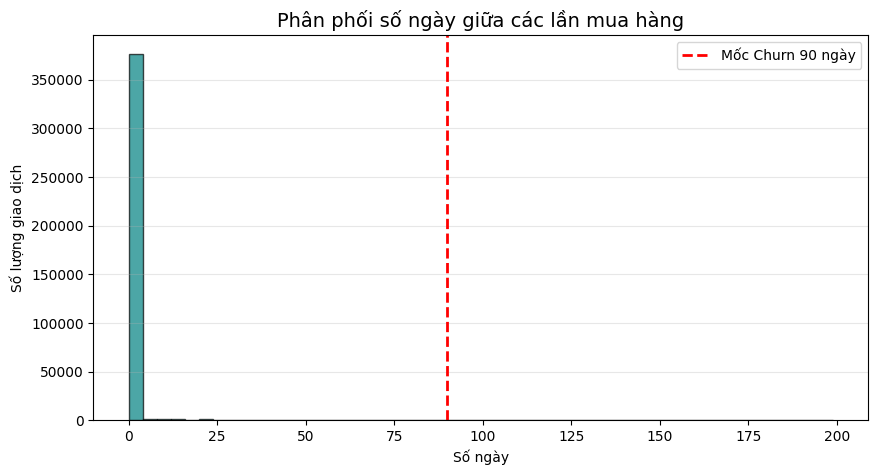

In [52]:
# 1. Tính khoảng cách (số ngày) giữa các lần mua của từng khách hàng
df_ipt = df1.sort_values(['CustomerID', 'InvoiceDate'])
df_ipt['Prev_Date'] = df_ipt.groupby('CustomerID')['InvoiceDate'].shift(1)
df_ipt['Days_Between'] = (df_ipt['InvoiceDate'] - df_ipt['Prev_Date']).dt.days

# 2. Lấy các giá trị khoảng cách (loại bỏ các giá trị NaN do lần mua đầu tiên)
ipt_values = df_ipt['Days_Between'].dropna()

# 3. Tính toán các phân vị quan trọng
median_ipt = ipt_values.median()
p75_ipt = ipt_values.quantile(0.75)
p90_ipt = ipt_values.quantile(0.90)

print("PHÂN TÍCH KHOẢNG CÁCH MUA HÀNG (INTER-PURCHASE TIME)")
print(f"Trung vị (Median): {median_ipt} ngày")
print(f"75% khách hàng quay lại trong vòng: {p75_ipt} ngày")
print(f"90% khách hàng quay lại trong vòng: {p90_ipt} ngày")

# 4. Vẽ biểu đồ phân phối để đưa vào báo cáo
plt.figure(figsize=(10, 5))
plt.hist(ipt_values[ipt_values < 200], bins=50, color='teal', edgecolor='black', alpha=0.7)
plt.axvline(90, color='red', linestyle='--', linewidth=2, label='Mốc Churn 90 ngày')
plt.title("Phân phối số ngày giữa các lần mua hàng", fontsize=14)
plt.xlabel("Số ngày")
plt.ylabel("Số lượng giao dịch")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### **Thiết lập cửa sổ quan sát và Feature Engineering nâng cao (với ngưỡng thống kê)**

In [ ]:

def safe_div(a, b):
    if pd.isna(b) or b == 0:
        return np.nan
    return a / b

def calc_order_level_dates(group):
    """Lấy lịch sử mua theo cấp invoice để tính IPT chính xác."""
    tmp = group[['InvoiceNo', 'InvoiceDate']].drop_duplicates().sort_values('InvoiceDate')
    return tmp

def calc_ipt_features(group, cutoff):
    orders = calc_order_level_dates(group)
    dates = orders['InvoiceDate'].sort_values()

    # Khởi tạo giá trị mặc định là NaN
    avg_interval = np.nan
    med_interval = np.nan # Cột quan trọng để sửa lỗi KeyError
    std_interval = np.nan
    churn_threshold = np.nan
    is_exceeding_threshold = 0

    if len(dates) >= 2:
        diffs = dates.diff().dropna().dt.days
        avg_interval = diffs.mean()
        med_interval = diffs.median() # Tính toán trung vị khoảng cách mua hàng
        std_interval = diffs.std()

        # Áp dụng công thức mu + 2*sigma
        sigma = std_interval if pd.notna(std_interval) else 0
        churn_threshold = avg_interval + (2 * sigma)

    recency = (cutoff - dates.max()).days
    if pd.notna(churn_threshold):
        is_exceeding_threshold = 1 if recency > churn_threshold else 0

    return pd.Series({
        'Average_Purchase_Interval': avg_interval,
        'Median_Purchase_Interval': med_interval, # Trả về đầy đủ cho build_snapshot
        'Std_Purchase_Interval': std_interval,
        'Churn_Threshold_Stat': churn_threshold,
        'Is_Exceeding_Threshold': is_exceeding_threshold,
        'Anomaly_Drop_Rate': safe_div(recency, avg_interval)
    })

def build_snapshot(df_full, cutoff, horizon_days=90, active_window_days=180):
    """
    Hàm tạo snapshot dữ liệu tại một thời điểm cutoff.
    df_full: DataFrame đầy đủ (chứa cả hàng trả/hủy)
    """
    cutoff = pd.Timestamp(cutoff)
    future_end = cutoff + pd.Timedelta(days=horizon_days)

    # 1. Tách dữ liệu Quá khứ và Tương lai
    obs_all = df_full[df_full['InvoiceDate'] <= cutoff].copy()
    future = df_full[(df_full['InvoiceDate'] > cutoff) & (df_full['InvoiceDate'] <= future_end)].copy()

    # 2. Lọc Active Customers (Khách có phát sinh giao dịch trong active_window)
    active_start = cutoff - pd.Timedelta(days=active_window_days)
    active_ids = obs_all[obs_all['InvoiceDate'] > active_start]['CustomerID'].unique()
    obs_all = obs_all[obs_all['CustomerID'].isin(active_ids)].copy()

    if obs_all.empty: return pd.DataFrame()
    
    # TÍNH TOÁN HÀNH VI TRẢ HÀNG/HỦY ĐƠN
    # Tính toán trên obs_all (gồm cả âm và dương)
    behavior_feat = obs_all.groupby('CustomerID').agg(
        cancel_invoice_count=('is_cancel', 'sum'),
        return_txn_count=('is_return', 'sum'),
        total_return_amount=('TotalAmount', lambda x: abs(x[x < 0].sum())),
        total_gross_spend=('TotalAmount', lambda x: x[x > 0].sum())
    ).reset_index()

    # Tính tỷ lệ tiền trả lại (return_ratio)
    behavior_feat['return_amount_ratio'] = (
        behavior_feat['total_return_amount'] / (behavior_feat['total_gross_spend'] + 0.01)
    )

    # CHUẨN BỊ DỮ LIỆU SẠCH ĐỂ TÍNH RFM & IPT 
    # Chỉ lấy các giao dịch thành công (Quantity > 0) để các chỉ số không bị lệch
    obs = obs_all[(obs_all['Quantity'] > 0) & (obs_all['UnitPrice'] > 0)].copy()
    # Đảm bảo có cột Total_price để khớp với code cũ của bạn
    obs['Total_price'] = obs['Quantity'] * obs['UnitPrice']

    # 3. Tính toán RFM & Basket Size (trên dữ liệu sạch)
    rfm_feat = obs.groupby('CustomerID').agg(
        Recency=('InvoiceDate', lambda x: (cutoff - x.max()).days),
        Frequency=('InvoiceNo', 'nunique'),
        Monetary=('Total_price', 'sum'),
        Basket_Size=('Quantity', 'mean')
    ).reset_index()

    # 4. Avg Order Value
    order_value = (
        obs.groupby(['CustomerID', 'InvoiceNo'], as_index=False)['Total_price'].sum()
        .groupby('CustomerID', as_index=False)['Total_price'].mean()
        .rename(columns={'Total_price': 'Avg_Order_Value'})
    )

    # 5. Velocity features (30d vs 90d)
    period_30 = cutoff - pd.Timedelta(days=30)
    period_90 = cutoff - pd.Timedelta(days=90)

    def velocity_block(g):
        orders_30 = g[g['InvoiceDate'] > period_30]['InvoiceNo'].nunique()
        orders_prev = g[(g['InvoiceDate'] > period_90) & (g['InvoiceDate'] <= period_30)]['InvoiceNo'].nunique()
        spend_30 = g[g['InvoiceDate'] > period_30]['Total_price'].sum()
        spend_prev = g[(g['InvoiceDate'] > period_90) & (g['InvoiceDate'] <= period_30)]['Total_price'].sum()
        return pd.Series({
            'orders_last_30d': orders_30, 'orders_prev_60d': orders_prev,
            'spend_last_30d': spend_30, 'spend_prev_60d': spend_prev
        })

    velocity = obs.groupby('CustomerID').apply(velocity_block, include_groups=False).reset_index()
    velocity['order_slope'] = velocity['orders_last_30d'] - (velocity['orders_prev_60d'] / 2)
    velocity['spend_slope'] = velocity['spend_last_30d'] - (velocity['spend_prev_60d'] / 2)

    # 6. IPT features
    ipt_feat = obs.groupby('CustomerID').apply(lambda g: calc_ipt_features(g, cutoff), include_groups=False).reset_index()

    # 7. Merge tất cả lại thành bảng Feature hoàn chỉnh
    features = rfm_feat.merge(order_value, on='CustomerID', how='left')\
                       .merge(velocity, on='CustomerID', how='left')\
                       .merge(ipt_feat, on='CustomerID', how='left')\
                       .merge(behavior_feat[['CustomerID', 'cancel_invoice_count', 'return_amount_ratio']], on='CustomerID', how='left')

    # Điền giá trị thiếu cho các feature mới
    features['cancel_invoice_count'] = features['cancel_invoice_count'].fillna(0)
    features['return_amount_ratio'] = features['return_amount_ratio'].fillna(0)

    # Điền giá trị thiếu cho các feature cũ
    features['Anomaly_Drop_Rate'] = features['Anomaly_Drop_Rate'].fillna(1.0)
    for col in ['Average_Purchase_Interval', 'Median_Purchase_Interval', 'Std_Purchase_Interval']:
        features[col] = features[col].fillna(features[col].median())

    # 8. Gán nhãn Churn (Target Y) - Lưu ý: Chỉ tính Churn trên những khách có trong obs_clean
    bought_in_future = set(future[future['Quantity'] > 0]['CustomerID'].unique())
    features['churn_label'] = (~features['CustomerID'].isin(bought_in_future)).astype(int)
    features['snapshot_date'] = cutoff

    return features



In [65]:

# C. Xây nhiều snapshot để split theo thời gian

train_cutoffs = [
    pd.Timestamp('2011-05-31'),
    pd.Timestamp('2011-06-30'),
    pd.Timestamp('2011-07-31'),
    pd.Timestamp('2011-08-31')
]

# Holdout snapshot đúng với hướng báo cáo của nhóm
test_cutoff = pd.Timestamp('2011-09-09')

all_cutoffs = train_cutoffs + [test_cutoff]

snapshot_list = []

for c in all_cutoffs:
    print(f"--- Đang xử lý Snapshot: {c.date()} ---")

    # GỌI HÀM: build_snapshot bây giờ trả về 1 DataFrame duy nhất đã có đủ Feature & Label
    snap_df = build_snapshot(df_full, cutoff=c, horizon_days=90, active_window_days=180)

    if not snap_df.empty:
        snapshot_list.append(snap_df)
        print(f"Hoàn thành: {len(snap_df)} khách hàng.")

# Gộp tất cả thành bảng Master
model_df = pd.concat(snapshot_list, ignore_index=True)


--- Đang xử lý Snapshot: 2011-05-31 ---
Hoàn thành: 2681 khách hàng.
--- Đang xử lý Snapshot: 2011-06-30 ---
Hoàn thành: 2729 khách hàng.
--- Đang xử lý Snapshot: 2011-07-31 ---
Hoàn thành: 2790 khách hàng.
--- Đang xử lý Snapshot: 2011-08-31 ---
Hoàn thành: 2798 khách hàng.
--- Đang xử lý Snapshot: 2011-09-09 ---
Hoàn thành: 2800 khách hàng.


In [66]:

# D. Split theo thời gian (KHÔNG random split)

# Tách Train và Test dựa trên ngày cutoff đã lưu trong mỗi snapshot
train_df = model_df[model_df['snapshot_date'] < test_cutoff].copy()
test_df  = model_df[model_df['snapshot_date'] == test_cutoff].copy()

# Kiểm tra rò rỉ dữ liệu
assert train_df['snapshot_date'].max() < test_df['snapshot_date'].min(), \
    "Leakage: train và test không được chồng thời gian"

# Danh sách các cột tính năng (Phải khớp chính xác với kết quả từ hàm build_snapshot)
feature_cols = [
    'Recency', 'Frequency', 'Monetary', 'Basket_Size', 'Avg_Order_Value',
    'orders_last_30d', 'orders_prev_60d',
    'spend_last_30d', 'spend_prev_60d',
    'order_slope', 'spend_slope',
    'Average_Purchase_Interval', 'Median_Purchase_Interval',
    'Std_Purchase_Interval', 'Anomaly_Drop_Rate', 'Is_Exceeding_Threshold',
    'cancel_invoice_count', 'return_amount_ratio'  # <-- 2 cột mới giúp giải quyết Lỗi 3
]

X_train = train_df[feature_cols].copy()
y_train = train_df['churn_label'].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df['churn_label'].copy()

print("\n" + "="*30)
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")
print("="*30)



Train shape: (10998, 18) | Test shape: (2800, 18)
Train churn rate: 45.48%
Test churn rate: 38.71%


In [67]:

# E. Baseline Logistic Regression
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
pr_auc_lr = average_precision_score(y_test, y_prob_lr)

print(f"Logistic Regression PR-AUC: {pr_auc_lr:.4f}")


Logistic Regression PR-AUC: 0.6039


In [68]:

# F. XGBoost model

ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

print(f"XGBoost PR-AUC: {pr_auc_xgb:.4f}")



XGBoost PR-AUC: 0.7087


In [70]:

# G. Chọn model tốt hơn theo PR-AUC
if pr_auc_xgb >= pr_auc_lr:
    best_model_name = 'XGBoost'
    best_model = xgb_model
    y_prob = y_prob_xgb
else:
    best_model_name = 'Logistic Regression'
    best_model = lr_model
    y_prob = y_prob_lr

print(f"\nBest model = {best_model_name}")




Best model = XGBoost


In [72]:

# H. Threshold tuning + cost table 

COST_INTERVENTION = 50_000
VALUE_SAVED = 500_000
P_SAVE = 0.25      # Xác suất khách hàng đồng ý ở lại khi được chăm sóc
CAPACITY = 300     # Giới hạn năng lực (chỉ gọi được tối đa 300 khách/tháng)

threshold_grid = np.round(np.arange(0.05, 0.96, 0.05), 2)

rows = []
for th in threshold_grid:
    y_pred = (y_prob >= th).astype(int)

    tp = int(((y_pred == 1) & (y_test == 1)).sum())
    fp = int(((y_pred == 1) & (y_test == 0)).sum())
    fn = int(((y_pred == 0) & (y_test == 1)).sum())
    tn = int(((y_pred == 0) & (y_test == 0)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    contacted = tp + fp

    # Sửa công thức Profit thành dạng Kỳ vọng (Expected Profit)
    # Lợi nhuận = (Số khách cứu được * Giá trị cứu được) - (Tổng số khách liên hệ * Chi phí)
    expected_profit = (tp * P_SAVE * VALUE_SAVED) - (contacted * COST_INTERVENTION)

    rows.append({
        'threshold': th,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'precision': precision,
        'recall': recall,
        'contacted': contacted,
        'profit': expected_profit # Đây là Expected Profit
    })

threshold_table = pd.DataFrame(rows).sort_values('threshold')

# TÌM THRESHOLD TỐI ƯU DƯỚI RÀNG BUỘC CAPACITY (Lọc những dòng có contacted <= 300)
# Nếu không có ngưỡng nào <= 300, ta lấy ngưỡng có contacted thấp nhất
feasible_rows = threshold_table[threshold_table['contacted'] <= CAPACITY]

if not feasible_rows.empty:
    best_row = feasible_rows.loc[feasible_rows['profit'].idxmax()]
else:
    # Trường hợp dự phòng nếu mọi ngưỡng đều > 300 khách
    best_row = threshold_table.sort_values('contacted').iloc[0]

best_thresh = float(best_row['threshold'])

print(f"=== Threshold comparison table (Capacity Limit: {CAPACITY}) ===")
print(threshold_table)

print(f"\nOptimal threshold (Feasible) = {best_thresh:.2f}")
print(f"Expected profit              = {best_row['profit']:,.0f} VNĐ")
print(f"Number of customers to call  = {best_row['contacted']} (Năng lực: {CAPACITY})")


=== Threshold comparison table (Capacity Limit: 300) ===
    threshold    tp    fp    fn    tn  precision    recall  contacted  \
0        0.05  1082  1467     2   249   0.424480  0.998155       2549   
1        0.10  1078  1328     6   388   0.448047  0.994465       2406   
2        0.15  1067  1215    17   501   0.467572  0.984317       2282   
3        0.20  1052  1112    32   604   0.486137  0.970480       2164   
4        0.25  1034  1001    50   715   0.508108  0.953875       2035   
5        0.30  1013   913    71   803   0.525961  0.934502       1926   
6        0.35   986   848    98   868   0.537623  0.909594       1834   
7        0.40   964   743   120   973   0.564733  0.889299       1707   
8        0.45   910   633   174  1083   0.589760  0.839483       1543   
9        0.50   832   508   252  1208   0.620896  0.767528       1340   
10       0.55   742   405   342  1311   0.646905  0.684502       1147   
11       0.60   606   287   478  1429   0.678611  0.559041        8

In [74]:

# I. Evaluation tại threshold tối ưu

y_pred_opt = (y_prob >= best_thresh).astype(int)

print("\n=== Classification Report @ optimal threshold ===")
print(classification_report(y_test, y_pred_opt, target_names=['Active', 'Churn']))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_opt))

print(f"\nPR-AUC ({best_model_name}) = {average_precision_score(y_test, y_prob):.4f}")




=== Classification Report @ optimal threshold ===
              precision    recall  f1-score   support

      Active       0.64      0.99      0.78      1716
       Churn       0.86      0.12      0.20      1084

    accuracy                           0.65      2800
   macro avg       0.75      0.55      0.49      2800
weighted avg       0.73      0.65      0.56      2800


=== Confusion Matrix ===
[[1696   20]
 [ 958  126]]

PR-AUC (XGBoost) = 0.7087


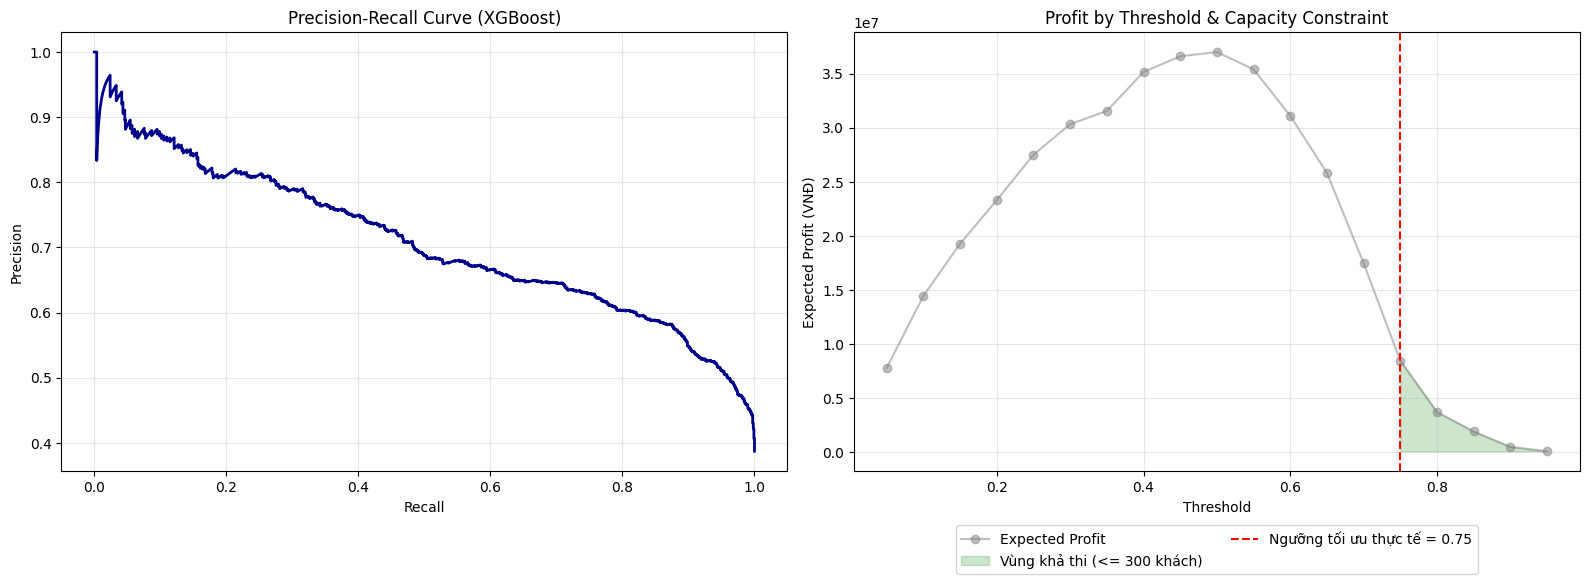

In [75]:

# J. Vẽ PR curve + Profit curve (ĐÃ CẬP NHẬT THEO LỖI 2)

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Biểu đồ Precision-Recall Curve
axes[0].plot(recalls[:-1], precisions[:-1], linewidth=2, color='darkblue')
axes[0].set_title(f'Precision-Recall Curve ({best_model_name})', fontsize=12)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].grid(True, alpha=0.3)

# 2. Biểu đồ Lợi nhuận theo Ngưỡng (Profit by Threshold)
# Vẽ đường lợi nhuận kỳ vọng
axes[1].plot(threshold_table['threshold'], threshold_table['profit'],
             marker='o', linestyle='-', color='gray', alpha=0.5, label='Expected Profit')

# Tô màu xanh cho Vùng khả thi (Năng lực gọi <= 300 khách)
# Giả định CAPACITY = 300 đã khai báo ở Mục H
axes[1].fill_between(threshold_table['threshold'],
                     threshold_table['profit'].min(),
                     threshold_table['profit'],
                     where=(threshold_table['contacted'] <= 300),
                     color='green', alpha=0.2, label='Vùng khả thi (<= 300 khách)')

# Vẽ đường thẳng tại ngưỡng tối ưu thực tế (best_thresh đã tính ở Mục H)
axes[1].axvline(best_thresh, linestyle='--', color='red',
                label=f'Ngưỡng tối ưu thực tế = {best_thresh:.2f}')

axes[1].set_title('Profit by Threshold & Capacity Constraint', fontsize=12)
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Expected Profit (VNĐ)')
axes[1].legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




=== Feature Importance ===
                      feature  importance
1                   Frequency    0.432763
2                    Monetary    0.071195
8              spend_prev_60d    0.068100
17        return_amount_ratio    0.040141
13      Std_Purchase_Interval    0.034875
12   Median_Purchase_Interval    0.033829
0                     Recency    0.032242
4             Avg_Order_Value    0.031520
11  Average_Purchase_Interval    0.031054
14          Anomaly_Drop_Rate    0.029665
10                spend_slope    0.029636
16       cancel_invoice_count    0.027974
3                 Basket_Size    0.027765
15     Is_Exceeding_Threshold    0.027239
7              spend_last_30d    0.023904
5             orders_last_30d    0.020652
9                 order_slope    0.019303
6             orders_prev_60d    0.018144


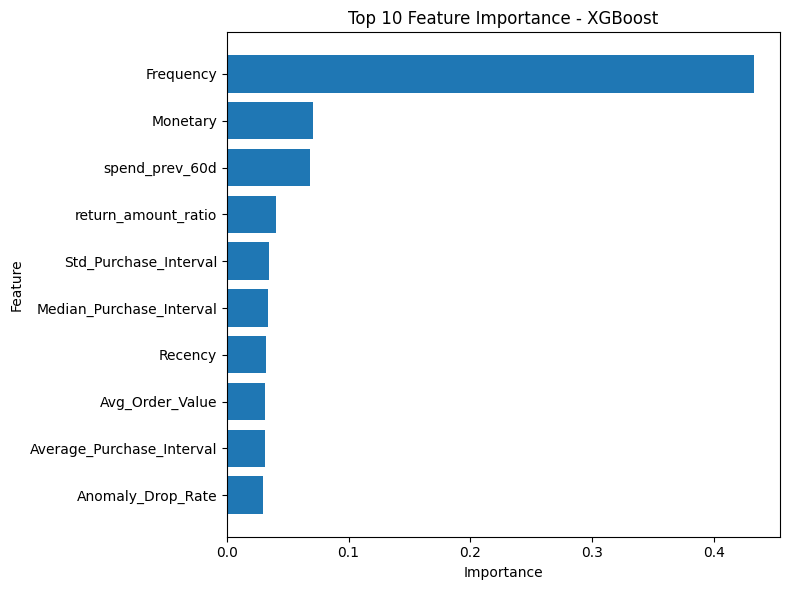

In [76]:

# K. Feature importance

if best_model_name == 'XGBoost':
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
else:
    coef = best_model.named_steps['clf'].coef_[0]
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': np.abs(coef)
    }).sort_values('importance', ascending=False)

print("\n=== Feature Importance ===")
print(importance_df)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'].head(10)[::-1], importance_df['importance'].head(10)[::-1])
plt.title(f'Top 10 Feature Importance - {best_model_name}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [77]:

# L. Scoring trên snapshot holdout để ra action list

test_df = test_df.copy()
test_df['churn_prob'] = y_prob

def classify_risk(p, threshold):
    if p >= 0.90:
        return 'Lost Cause (>90%)'
    elif p >= threshold:
        return 'Persuadable'
    elif p >= 0.30:
        return 'At-Risk (Low)'
    else:
        return 'Active'

test_df['risk_segment'] = test_df['churn_prob'].apply(lambda p: classify_risk(p, best_thresh))

print("\n=== Risk Segment Distribution ===")
print(test_df['risk_segment'].value_counts())

target_list = (
    test_df[test_df['risk_segment'] == 'Persuadable']
    .sort_values('churn_prob', ascending=False)
    [[
        'CustomerID',
        'Recency', 'Frequency', 'Monetary',
        'Average_Purchase_Interval',
        'Anomaly_Drop_Rate',
        'order_slope', 'spend_slope',
        'churn_prob'
    ]]
)

print(f"\nSố khách hàng cần can thiệp: {len(target_list)}")
display(target_list.head(20))




=== Risk Segment Distribution ===
risk_segment
At-Risk (Low)        1780
Active                874
Persuadable           138
Lost Cause (>90%)       8
Name: count, dtype: int64

Số khách hàng cần can thiệp: 138


,CustomerID,Recency,Frequency,Monetary,Average_Purchase_Interval,Anomaly_Drop_Rate,order_slope,spend_slope,churn_prob
12606,15695,174,2,409.98,0.000000,1.000000,0.0,0.000,0.899030
13684,18048,111,2,172.29,0.000000,1.000000,0.0,0.000,0.880101
12139,14682,95,2,52.00,13.000000,7.307692,0.0,0.000,0.878611
12406,15235,125,12,2247.51,13.727273,9.105960,0.0,0.000,0.875489
12521,15508,97,6,1000.27,8.800000,11.022727,0.0,0.000,0.874393
12824,16163,140,2,856.60,132.000000,1.060606,0.0,0.000,0.874295
12149,14697,126,2,188.61,0.000000,1.000000,0.0,0.000,0.872683
12775,16063,168,1,335.32,0.000000,1.000000,0.0,0.000,0.872681
11278,12908,84,2,750.00,136.000000,0.617647,-0.5,-216.000,0.869799
13078,16716,174,2,901.20,44.000000,3.954545,0.0,0.000,0.866526


In [78]:

# M. Hồ sơ nhóm khách nguy cơ cao

high_risk_profile = (
    test_df.groupby('risk_segment')[[
        'Recency', 'Frequency', 'Monetary',
        'Average_Purchase_Interval', 'Anomaly_Drop_Rate',
        'order_slope', 'spend_slope'
    ]]
    .mean()
    .sort_index()
)

print("\n=== High Risk Profile ===")
display(high_risk_profile)



=== High Risk Profile ===


,Recency,Frequency,Monetary,Average_Purchase_Interval,Anomaly_Drop_Rate,order_slope,spend_slope
risk_segment,,,,,,,
Active,30.556064,8.486270,4408.775275,40.325901,1.177741,0.001144,15.515732
At-Risk (Low),78.700000,1.903933,625.375636,65.042039,1.302923,0.036517,13.263438
Lost Cause (>90%),122.875000,4.000000,11234.942500,11.216071,8.157466,0.000000,0.000000
Persuadable,125.485507,1.927536,521.367536,43.807953,4.523382,-0.159420,-14.896848


In [37]:
import pandas as pd

summary_data = {
    "Metric": ["Model", "PR-AUC", "Optimal Threshold", "Customers Contacted", "Expected Profit (VNĐ)"],
    "Logistic Regression": ["Baseline", f"{pr_auc_lr:.4f}", "-", "-", "-"],
    "XGBoost": ["Best Model", f"{pr_auc_xgb:.4f}", f"{best_thresh}", f"{best_row['contacted']}", f"{best_row['profit']:,.0f}"]
}

summary_table = pd.DataFrame(summary_data)
display(summary_table)

,Metric,Logistic Regression,XGBoost
0,Model,Baseline,Best Model
1,PR-AUC,0.6039,0.7087
2,Optimal Threshold,-,0.75
3,Customers Contacted,-,146.0
4,Expected Profit (VNĐ),-,"8,450,000"
